RAPPRESENTAZIONE DELLE IMMAGINI COME ARRAY

Immagina di guardare un'opera d'arte, da lontano vedi un paesaggio, ma da vicino vedo solo i punti di colore isalti.
Nel mondo digitale facciamo l'esatto opposto, prendiamo la complessità della visoine e la bricioliamo in una grigli ordinata di numeri.

- Anatomia dei tensori visivi
- Ottimizzazione della memoria e precisione, per salvare una foto usiamo un linguaggio ma per addestrare un cervello artificiale ne usiamo un altro molto più preciso
- Logia di binarizzazione, come passare dal caos del colore alla logica binaria del bianco/nero

Un'immagine digitale, per Python e per una rete neurale, non è una fotografica, è una struttura numerica composta da righe, colonne, e canali (matrice di array multidimensinale)

Per lavorare con le immagini si usa normalmente NumPy

*** IMMAGINE IN SCALA DI GRIGI ***
- Immagine in scala di grigi: un'immagine in scala di grigi può essere rappresentata con una matrice bidimensionale

     colonna0 colonna 1 colonna 2
riga0
riga1
riga2
Ogni numero rappresenta la luminosità di un pixel
0=nero 255=bianc valori intermedi=intervalli di grigio

La forma dell'array
immagnie.shape è (3,3) altezza=3, larghezza=3

Il pixel è un elemento dell'array
valore=immagine[1,2] leggendo riga 1 colonna 2 (y,x)

*** IMMAGINE A COLORI RGB ***

Un'immagine RGB non contiene un singolo valore per i pixel, ma tra valori
immagine_rgb = np.array([
    [
        [255, 0, 0],
        [0, 255, 0]
    ],
    [
        [0, 0, 255],
        [255, 255, 255]
    ]
], dtype=np.uint8)
La sua forma è (2,2,3)
2 pixel per altezza
2 pixel per larghezza
3 canali
shape(altezza, larghezza, canali)

Per leggere un pixel in posizione riga 0, colonna 1:
pixel=immagine_rgb[0,1]  risultato [0  255  0]
Possiamo leggere un solo canale:
rosso = immagine_rgb[0, 1, 0]
verde = immagine_rgb[0, 1, 1]
blu = immagine_rgb[0, 1, 2]

*** RGB e BGR ***

Pillow, Matplotlib, e scikit-image lavorano normalmente in RGB
OpenCV tradizionalmente BGR

*** TIPI DI DATO ***

I sensori catturano immagini in formati discreti, solitamento a 8 bit per canale. Tuttavia, per l'addestramento dei modelli, abbiamo bisogno di una risoluzione numerica molto più alta.
Una scala errata può saturare la memoria o impedire la convergenza del gradiente durante l'ottimizzazione.

unit8 vs float32

- unit8: intero senza segno a 8 bit. Rappresenta valore da 0 a 255 ed è lo standard per il salvataggio su disco (JPEG/PNG). Leggero e perfetto per il disco fisso.
- float32: virgola mobile a 32 bi. Essenziale per le operazioni matematiche complesse e per rappresentare i pesi dei modelli. Da utilizzare per addestrare un modello, perchè durante il calcolo ci sono valori infinitesimali
- Normalizzazione: processo di trasformazione del range [0,255] nel range [0.0,1.0] tipicamente richiesto dalle reti neurali
- Consumo di memoria: array 'float32' occupa esattamente 4 volte lo spazio di un array unit8 a parità di risoluzione. Molto più preciso, ma molto più pesante.


*** NORMALIZZAZIONE ***

Le immagini lette da file contengono spesso valori tra 0 e 255
Per una rete neurale si trasformano tra 0 e 1
immagine_normalizzata = immagine_rgb.astype(np.float32) / 255.0

Spesso si aggiunge anche la STANDARIZZAZIONE sottraendo la media e si divide per la deviazione standard, per centrare i dati attorno allo zero, migliorando la stabilità del training.

*** SEMPLIFICAZIONE DATI ***

Una volta normalizzati i dati, possiamo decidere di semplificarli.
A volte il colore è solo rumore, saper se il bullone è blu o grigio non conta, conta solo la sua forma.
Concentriamoci sull'essenziale
Possiamo passare alla SCALA DI GRIGI che riduce la memoria di 3 volte e semplifica drasticamente il calcolo delle feature
La BINARIZZAZIONE porta questo concetto (di ridurre la memoria) all'estrmo, riducendo ogni pixel a solo due stasti: bianco o nero. Questo è il punto di partenza per la segmentazione degli oggetti.

- GrayScale: un'immagine a canale singolo dove ogni pixel rappresenta esclusivamente l'intensità luminosa (Luminanza)
- Thresholdin (soglia): operazione che converte un'immagine in gridio in una binaria basandosi su un valore critico. Immagina di tracciare una linea e quelli sopra diventano bianchi, quelli sotto neri. E' l'equivalente di ritagliare dal giornale una forma
- Soglia Globale: l'uso di un unico valore di soglia per l'intera immagine, efficace solo in condizone di illuminazione uniforme
- Segmentazione: l'uso della binarizzazione per separare il soggetto (foregound) dallo sfondo (background)

Formula della LUMINANZA: per passare alla scalal di grigi non facciamo una media dei colori. L'occhio umano è più sensibile al verde, quindi i canali vengono pesati in modo differente.

Soglia ADATTIVA
Per immagini con ombre o luci variabili, si calcola una soglia locale per ogni pixel basandori sul suo vicinato, garantendo una binarizzazione robusta.

Metodo di OTSU
Un algoritmo che calcola automaticamente la soglia ottimale analizzando l'istogramma dell'immagine per minimizzare la varianza intra-classe


Scaricamento immagine casuale da internet...
Shape dell'immagine (H, W, C): (400, 600, 3)
Tipo di dato originale: uint8
Nuovo Dtype: float32 | Range: [0.00, 1.00]


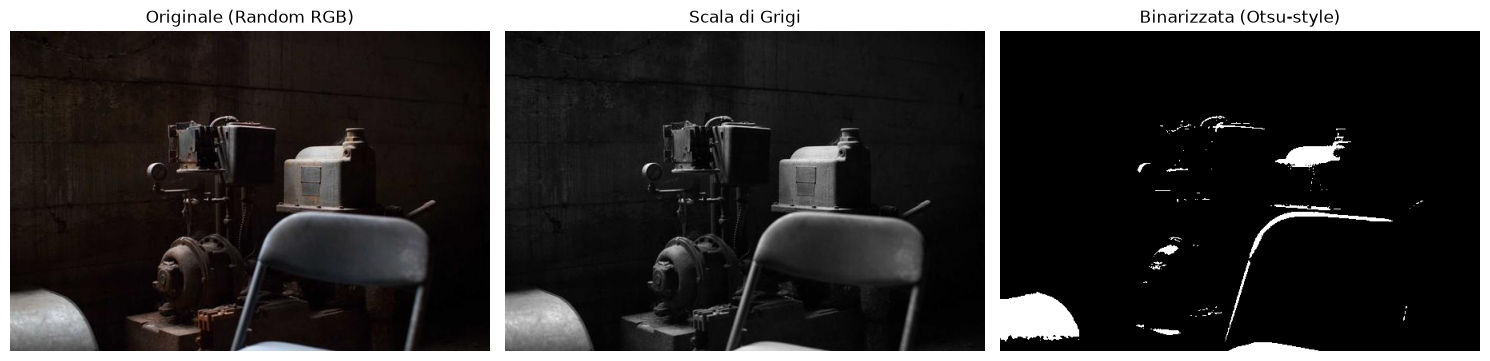

Risultato salvato come 'processed_random_result.png' con shape (400, 600, 1)


In [1]:
import os
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt
import keras
from io import BytesIO

# --- CONFIGURAZIONE BACKEND 2026 ---
os.environ["KERAS_BACKEND"] = "torch"

def explore_image_arrays():
    """
    Analisi pratica con download dinamico di un'immagine casuale.
    """
    
    # 1. DOWNLOAD IMMAGINE CASUALE
    print("Scaricamento immagine casuale da internet...")
    url = "https://picsum.photos/600/400" # Servizio per immagini random
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        # Convertiamo i byte della risposta in un array NumPy che OpenCV può leggere
        file_bytes = np.frombuffer(response.content, np.uint8)
        img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    except Exception as e:
        print(f"Errore durante il download: {e}")
        # Fallback: immagine sintetica in caso di mancanza di connessione
        img_bgr = np.random.randint(0, 256, (400, 600, 3), dtype=np.uint8)

    # Convertiamo in RGB (OpenCV legge in BGR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print(f"Shape dell'immagine (H, W, C): {img_rgb.shape}")
    print(f"Tipo di dato originale: {img_rgb.dtype}")

    # 2. CONVERSIONE E NORMALIZZAZIONE
    # Teoria: La normalizzazione in [0, 1] previene saturazioni nei calcoli.
    img_float = img_rgb.astype(np.float32) / 255.0
    print(f"Nuovo Dtype: {img_float.dtype} | Range: [{img_float.min():.2f}, {img_float.max():.2f}]")

    # 3. RIDUZIONE DIMENSIONALE (Grayscale)
    # Formula Luminanza: Y = 0.299R + 0.587G + 0.114B
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    
    # 4. BINARIZZAZIONE (Thresholding)
    _, img_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    # 5. VISUALIZZAZIONE COMPARATIVA
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Originale (Random RGB)")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Scala di Grigi")
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Binarizzata (Otsu-style)")
    plt.imshow(img_binary, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 6. SALVATAGGIO DINAMICO
    # Usiamo il metodo corretto per aggiungere la dimensione del canale (H, W, 1)
    img_to_save = np.expand_dims(img_binary, axis=-1)
    keras.utils.save_img("processed_random_result.png", img_to_save)
    print(f"Risultato salvato come 'processed_random_result.png' con shape {img_to_save.shape}")

if __name__ == "__main__":
    explore_image_arrays()